# 📊 Análisis Exploratorio de Datos (EDA) — Egresados SUNEDU 2022–2025

Este notebook realiza un **análisis exploratorio completo** de los egresados registrados en SUNEDU entre los años 2022 y 2025. Se consolidan los cuatro archivos anuales en un único DataFrame y se analizan todas las variables disponibles con visualizaciones descriptivas.

---
**Fuente de datos:** SUNEDU — Archivos `egresado_2022.csv`, `egresado_2023.csv`, `egresado_2024.csv`, `egresado_2025.csv`  
**Separador:** `|`  
**Codificación:** `latin-1`

## 0. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Estilo general (fondo blanco / default) ──────────────────────────────────
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#333333',
    'xtick.color':      '#333333',
    'ytick.color':      '#333333',
    'text.color':       '#333333',
    'grid.color':       '#CCCCCC',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#111111',
    'figure.titlesize': 16,
    'font.family':      'DejaVu Sans',
})

PALETTE   = ['#2196F3', '#9C27B0', '#F44336', '#00BCD4', '#FF9800', '#4CAF50']
CMAP_DIV  = 'coolwarm'
CMAP_SEQ  = 'viridis'

DATA_DIR  = Path('.')          # Carpeta actual (sunedu/)
YEARS     = [2022, 2023, 2024, 2025]

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga y Consolidación de Datos

In [2]:
dfs = []
for year in YEARS:
    filepath = DATA_DIR / f'egresado_{year}.csv'
    df_tmp = pd.read_csv(
        filepath,
        sep='|',
        encoding='latin-1',
        low_memory=False
    )
    # Asegurar que la columna ANIO refleja el año del archivo
    df_tmp['ANIO'] = year
    dfs.append(df_tmp)
    print(f'  📁 egresado_{year}.csv → {df_tmp.shape[0]:>7,} filas  |  {df_tmp.shape[1]} columnas')

df = pd.concat(dfs, ignore_index=True)
print(f'\n🔗 Dataset consolidado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

  📁 egresado_2022.csv → 167,735 filas  |  30 columnas
  📁 egresado_2023.csv → 171,695 filas  |  30 columnas
  📁 egresado_2024.csv → 158,610 filas  |  30 columnas
  📁 egresado_2025.csv →  89,487 filas  |  30 columnas

🔗 Dataset consolidado: 587,527 filas × 30 columnas


## 2. Inspección General del Dataset

In [3]:
print('=== Primeras 3 filas ===')
df.head(3)

=== Primeras 3 filas ===


,CODIGO_INEI,NOMBRE_ENTIDAD,TIPO_ENTIDAD,TIPO_GESTION,LICENCIADO,TIPO_CONSTITUCION,NIVEL_ACADEMICO,PERIODO_EGRESO,LOCAL_EGRESO,FECHA_EGRESO,...,NOMBRE_PROGRAMA,ES_SEDE_PRINCIPAL,CODIGO_SIU_FILIAL,DEPARTAMENTO_FILIAL,PROVINCIA_FILIAL,CREDITOS_APROBADOS,NOTA_PROMEDIO,DISCAPACITADO,ANIO,IDENTIFICADOR_PERSONA
0,260000052,Universidad César Vallejo S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-2,F03L01,2023-01-02 00:00:00.0000000,...,Contabilidad,NaN,F03,NaN,NaN,204.0,15.15,NO,2022,{5B7E7ADF-991C-46B3-AA42-3F7563652501}
1,260000055,Universidad Privada del Norte S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-1,F02L02,2022-07-19 00:00:00.0000000,...,Administración,NaN,F02,NaN,NaN,185.0,16.97,NO,2022,{62EDEC81-C921-42C0-8AE4-0CDD641D7366}
2,260000052,Universidad César Vallejo S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-1,F03L01,2022-08-10 00:00:00.0000000,...,Ingeniería Civil,NaN,F03,NaN,NaN,204.0,14.53,NO,2022,{E6199420-FC72-42F2-8040-9820CCDDB984}


In [4]:
print('=== Tipos de datos y valores no nulos ===')
df.info()

=== Tipos de datos y valores no nulos ===


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587527 entries, 0 to 587526
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CODIGO_INEI              587527 non-null  object 
 1   NOMBRE_ENTIDAD           587527 non-null  object 
 2   TIPO_ENTIDAD             587527 non-null  object 
 3   TIPO_GESTION             587527 non-null  object 
 4   LICENCIADO               587527 non-null  object 
 5   TIPO_CONSTITUCION        461770 non-null  object 
 6   NIVEL_ACADEMICO          587527 non-null  object 
 7   PERIODO_EGRESO           582954 non-null  object 
 8   LOCAL_EGRESO             587527 non-null  object 
 9   FECHA_EGRESO             587527 non-null  object 
 10  SEXO                     587527 non-null  object 
 11  NACIONALIDAD             582213 non-null  object 
 12  DEPARTAMENTO_NACIMIENTO  580305 non-null  object 
 13  ANIO_NACIMIENTO          587522 non-null  float64
 14  EDAD

In [5]:
# Estadísticas descriptivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODIGO_INEI,587527,139,260000052,80652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_ENTIDAD,587527,140,Universidad César Vallejo S.A.C.,80652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_ENTIDAD,587527,4,Universidad,578540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_GESTION,587527,2,Privado,461770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LICENCIADO,587527,3,Licenciada,553484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_CONSTITUCION,461770,2,Societaria- Con fines de lucro,284009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NIVEL_ACADEMICO,587527,4,Carrera Profesional,456444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PERIODO_EGRESO,582954,14,2023-2,100444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_EGRESO,587527,50,SL01,322405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FECHA_EGRESO,587527,1644,2023-12-15 00:00:00.0000000,9884,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Limpieza y Preprocesamiento

In [6]:
# ── Limpieza de columnas clave ───────────────────────────────────────────────
df.columns = df.columns.str.strip()

# 1. Eliminar columnas no necesarias
cols_drop = [
    'ES_SEDE_PRINCIPAL', 'DEPARTAMENTO_FILIAL', 'CODIGO_SIU_FILIAL',
    'PROVINCIA_FILIAL', 'LOCAL_EGRESO', 'CODIGO_GRUPO_1',
    'CODIGO_GRUPO_3', 'CODIGO_SIU_PROGRAMA', 'DEPARTAMENTO_NACIMIENTO',
    'EDAD'
]
cols_drop_exist = [c for c in cols_drop if c in df.columns]
df.drop(columns=cols_drop_exist, inplace=True)
print(f'✅ Columnas eliminadas: {cols_drop_exist}')

# 2. Convertir NOTA_PROMEDIO a numérico y rellenar nulos con el promedio
df['NOTA_PROMEDIO'] = pd.to_numeric(df['NOTA_PROMEDIO'], errors='coerce')
mean_nota = df['NOTA_PROMEDIO'].mean()
nulos_nota = df['NOTA_PROMEDIO'].isnull().sum()
df['NOTA_PROMEDIO'].fillna(mean_nota, inplace=True)
print(f'✅ NOTA_PROMEDIO: {nulos_nota} nulos rellenados con promedio {mean_nota:.2f}')

# 3. Corregir NACIONALIDAD: 'PAPÚ' → 'PERUANA', nulos → 'PERUANA'
nulos_nac = df['NACIONALIDAD'].isnull().sum()
papu_count = (df['NACIONALIDAD'] == 'PAPÚ').sum()
df['NACIONALIDAD'] = df['NACIONALIDAD'].replace({'PAPÚ': 'PERUANA'})
df['NACIONALIDAD'].fillna('PERUANA', inplace=True)
print(f'\n✅ NACIONALIDAD: {papu_count} registros PAPÚ → PERUANA, {nulos_nac} nulos → PERUANA')

# 4. TIPO_CONSTITUCION: nulos → 'Asociativa- Sin fines de lucro'
nulos_tc = df['TIPO_CONSTITUCION'].isnull().sum()
df['TIPO_CONSTITUCION'].fillna('Asociativa- Sin fines de lucro', inplace=True)
print(f'✅ TIPO_CONSTITUCION: {nulos_tc} nulos → Asociativa- Sin fines de lucro')

# 5. ANIO_NACIMIENTO: eliminar filas con nulos
df['ANIO_NACIMIENTO'] = pd.to_numeric(df['ANIO_NACIMIENTO'], errors='coerce')
nulos_anio = df['ANIO_NACIMIENTO'].isnull().sum()
df.dropna(subset=['ANIO_NACIMIENTO'], inplace=True)
print(f'✅ ANIO_NACIMIENTO: {nulos_anio} filas eliminadas por nulos')

# 6. PERIODO_EGRESO: conservar solo periodos X-1 y X-2; eliminar X-3, X-4, etc.;
#    nulos → asignar periodo 2 del año correspondiente (ANIO)
import re

def limpiar_periodo(row):
    periodo = row['PERIODO_EGRESO']
    anio = int(row['ANIO'])
    if pd.isnull(periodo):
        return f'{anio}-2'
    periodo_str = str(periodo).strip()
    m = re.match(r'^(\d{4})-(\d+)$', periodo_str)
    if m:
        sub = int(m.group(2))
        if sub in (1, 2):
            return periodo_str
        else:
            return None  # marcar para eliminar
    return None  # formato inesperado → eliminar

nulos_periodo_antes = df['PERIODO_EGRESO'].isnull().sum()
df['PERIODO_EGRESO'] = df.apply(limpiar_periodo, axis=1)
filas_invalidas = df['PERIODO_EGRESO'].isnull().sum()
df.dropna(subset=['PERIODO_EGRESO'], inplace=True)
print(f'\n✅ PERIODO_EGRESO: {nulos_periodo_antes} nulos asignados al periodo 2 del año,')
print(f'   {filas_invalidas} filas con periodos distintos de 1/2 eliminadas.')

# 7. Eliminar registros de Institutos (TIPO_ENTIDAD == 'Instituto')
institutos_count = (df['TIPO_ENTIDAD'] == 'Instituto').sum()
df = df[df['TIPO_ENTIDAD'] != 'Instituto'].copy()
print(f'\n✅ TIPO_ENTIDAD: {institutos_count} registros de Instituto eliminados')

# 8. Conversiones adicionales
df['CREDITOS_APROBADOS'] = pd.to_numeric(df['CREDITOS_APROBADOS'], errors='coerce')
df['SEXO'] = df['SEXO'].str.strip().str.upper().replace({'M': 'Masculino', 'F': 'Femenino'})
df['DISCAPACITADO'] = df['DISCAPACITADO'].str.strip().str.upper()
df['LICENCIADO'] = df['LICENCIADO'].str.strip()

# 9. Calcular EDAD al momento del egreso
df['EDAD_EGRESO'] = df['ANIO'] - df['ANIO_NACIMIENTO']
df['EDAD_EGRESO'] = df['EDAD_EGRESO'].astype(float)
# Sanity filter: 15 - 90 años
df.loc[~df['EDAD_EGRESO'].between(15, 90), 'EDAD_EGRESO'] = np.nan
print(f'\n✅ EDAD_EGRESO calculada: media = {df["EDAD_EGRESO"].mean():.1f} años')

df.reset_index(drop=True, inplace=True)
print(f'\n✅ Limpieza completada')
print(f'   Registros finales: {len(df):,}')

✅ Columnas eliminadas: ['ES_SEDE_PRINCIPAL', 'DEPARTAMENTO_FILIAL', 'CODIGO_SIU_FILIAL', 'PROVINCIA_FILIAL', 'LOCAL_EGRESO', 'CODIGO_GRUPO_1', 'CODIGO_GRUPO_3', 'CODIGO_SIU_PROGRAMA', 'DEPARTAMENTO_NACIMIENTO', 'EDAD']
✅ NOTA_PROMEDIO: 20544 nulos rellenados con promedio 15.14

✅ NACIONALIDAD: 215 registros PAPÚ → PERUANA, 5314 nulos → PERUANA
✅ TIPO_CONSTITUCION: 125757 nulos → Asociativa- Sin fines de lucro
✅ ANIO_NACIMIENTO: 5 filas eliminadas por nulos

✅ PERIODO_EGRESO: 4573 nulos asignados al periodo 2 del año,
   2653 filas con periodos distintos de 1/2 eliminadas.

✅ TIPO_ENTIDAD: 312 registros de Instituto eliminados

✅ EDAD_EGRESO calculada: media = 29.4 años

✅ Limpieza completada
   Registros finales: 584,557


## 4. EDA — Variable por Variable

### 4.1 Distribución por Año (ANIO)

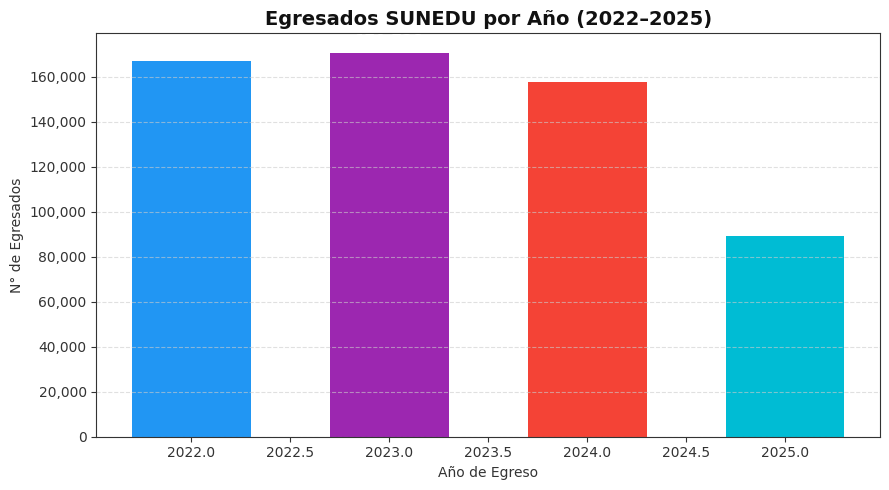

      Egresados  Porcentaje
ANIO                       
2022     166944       28.56
2023     170728       29.21
2024     157499       26.94
2025      89386       15.29


In [7]:
anio_counts = df['ANIO'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(anio_counts.index, anio_counts.values, color=PALETTE[:len(anio_counts)],
              edgecolor='none', width=0.6)
ax.set_xlabel('Año de Egreso')
ax.set_ylabel('N° de Egresados')
ax.set_title('Egresados SUNEDU por Año (2022–2025)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
for bar, val in zip(bars, anio_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{val:,}', ha='center', va='bottom', fontsize=11, color='#FFFFFF', fontweight='bold')
plt.tight_layout()
plt.show()

print(anio_counts.to_frame(name='Egresados').assign(Porcentaje=lambda x: (x['Egresados'] / x['Egresados'].sum() * 100).round(2)))

### 4.2 Distribución por Sexo

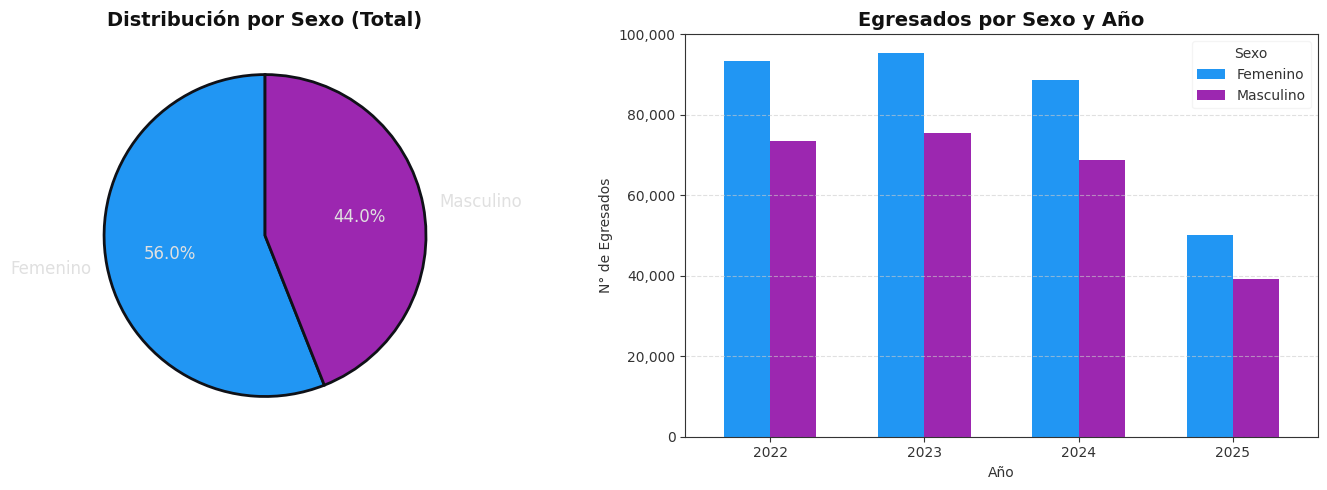

SEXO
Femenino     327370
Masculino    257187
Name: count, dtype: int64


In [8]:
sexo_counts = df['SEXO'].value_counts()
sexo_anio   = df.groupby(['ANIO', 'SEXO']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Torta
axes[0].pie(
    sexo_counts.values,
    labels=sexo_counts.index,
    autopct='%1.1f%%',
    colors=[PALETTE[0], PALETTE[1]],
    startangle=90,
    wedgeprops={'edgecolor': '#0F1117', 'linewidth': 2},
    textprops={'color': '#E0E0E0', 'fontsize': 12}
)
axes[0].set_title('Distribución por Sexo (Total)')

# Barras apiladas por año
sexo_anio.plot(kind='bar', ax=axes[1], color=[PALETTE[0], PALETTE[1]],
               edgecolor='none', width=0.6)
axes[1].set_title('Egresados por Sexo y Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('N° de Egresados')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Sexo', framealpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()
print(sexo_counts)

### 4.3 Tipo de Entidad y Tipo de Gestión

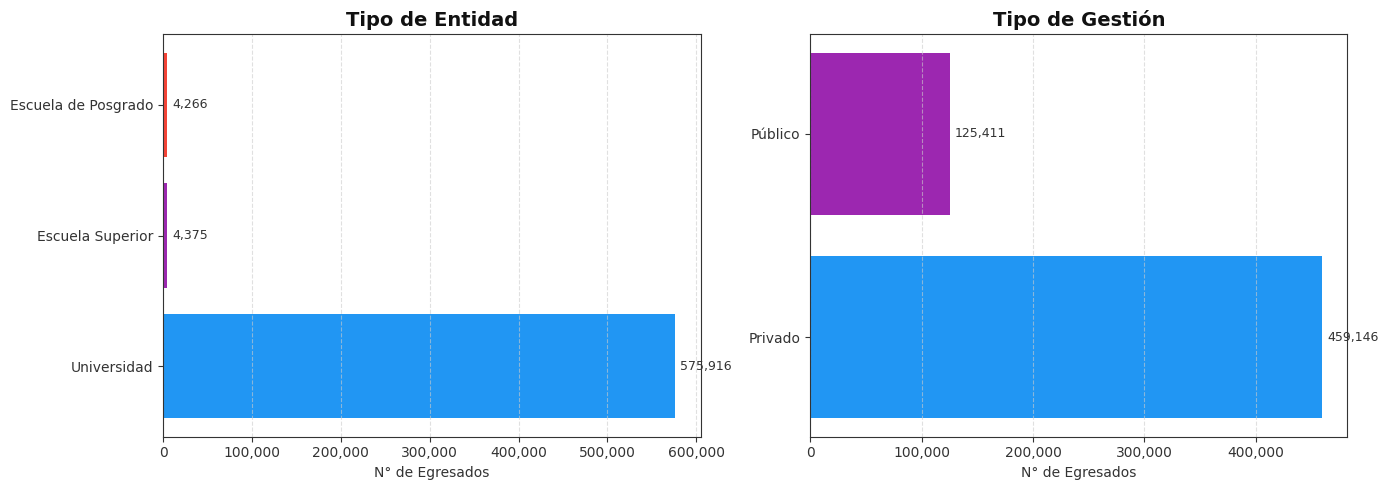

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['TIPO_ENTIDAD', 'TIPO_GESTION'],
    ['Tipo de Entidad', 'Tipo de Gestión']
):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=PALETTE[:len(counts)], edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel('N° de Egresados')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='x')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + counts.values.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9,)

plt.tight_layout()
plt.show()

### 4.4 Estado de Licenciamiento

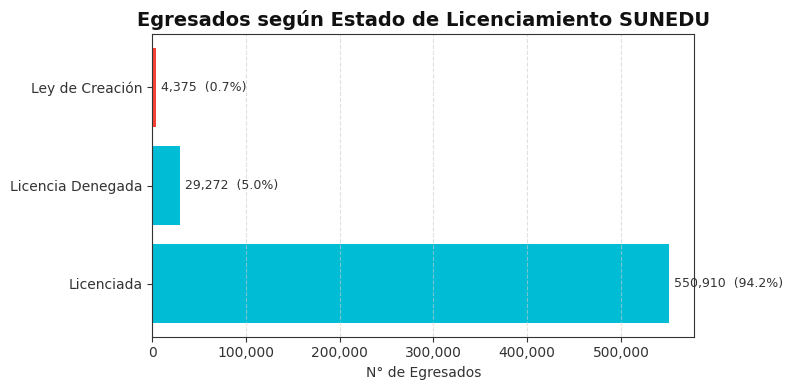

In [10]:
lic_counts = df['LICENCIADO'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors_lic = [PALETTE[3] if 'Licenc' in str(v) else PALETTE[2] for v in lic_counts.index]
bars = ax.barh(lic_counts.index, lic_counts.values, color=colors_lic, edgecolor='none')
ax.set_title('Egresados según Estado de Licenciamiento SUNEDU')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, lic_counts.values):
    ax.text(bar.get_width() + lic_counts.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9,)
plt.tight_layout()
plt.show()

### 4.5 Nivel Académico

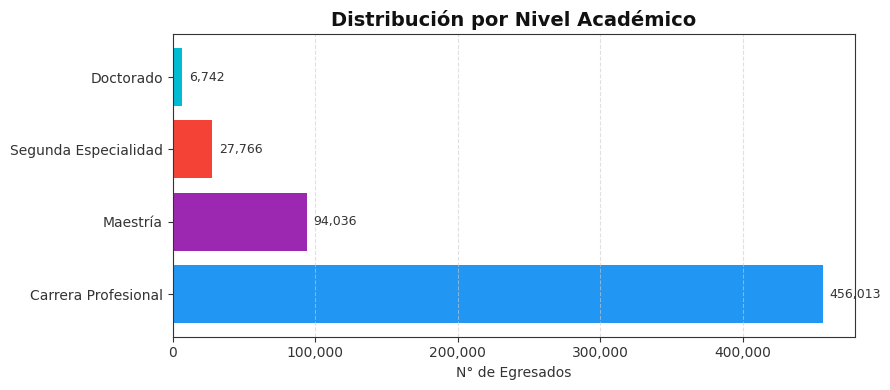

In [11]:
nivel_counts = df['NIVEL_ACADEMICO'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(nivel_counts.index, nivel_counts.values,
               color=PALETTE[:len(nivel_counts)], edgecolor='none')
ax.set_title('Distribución por Nivel Académico')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, nivel_counts.values):
    ax.text(bar.get_width() + nivel_counts.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, )
plt.tight_layout()
plt.show()

### 4.6 Tipo de Constitución

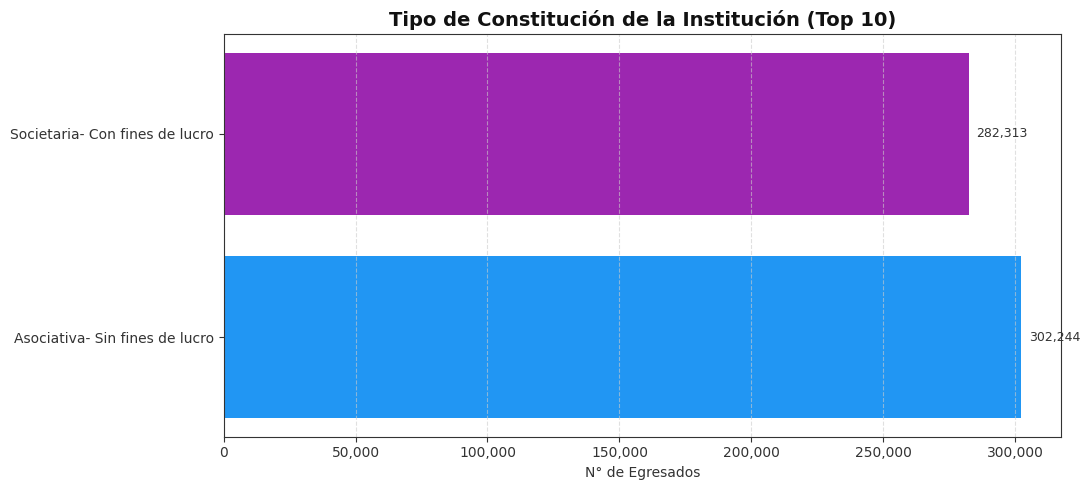

In [12]:
tipo_const = df['TIPO_CONSTITUCION'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(tipo_const.index, tipo_const.values,
               color=PALETTE[:len(tipo_const)], edgecolor='none')
ax.set_title('Tipo de Constitución de la Institución (Top 10)')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, tipo_const.values):
    ax.text(bar.get_width() + tipo_const.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, )
plt.tight_layout()
plt.show()

### 4.7 Distribución de Edad de Egresados

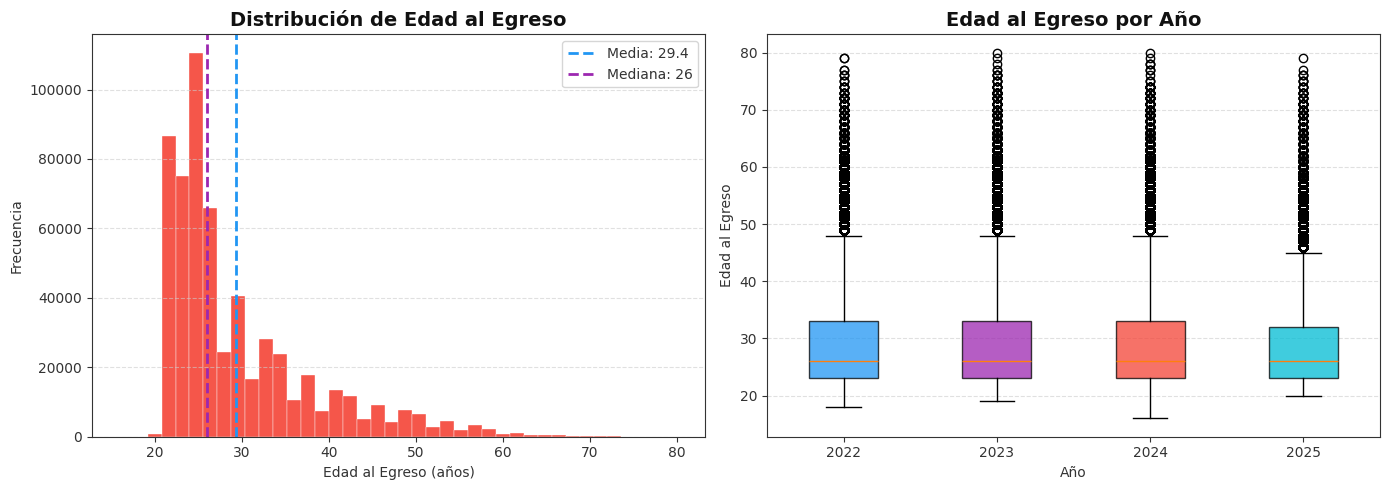

Estadísticas Edad al Egreso:
count    584552.00
mean         29.38
std           8.61
min          16.00
25%          23.00
50%          26.00
75%          33.00
max          80.00
Name: EDAD_EGRESO, dtype: float64

Edad media por año:
ANIO
2022    29.7
2023    29.3
2024    29.4
2025    29.0


In [13]:
# 4.7 Edad en el momento del egreso (ANIO - ANIO_NACIMIENTO)
edad_egreso = df['EDAD_EGRESO'].dropna()
edad_egreso = edad_egreso[(edad_egreso >= 15) & (edad_egreso <= 80)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(edad_egreso, bins=40, color=PALETTE[2], edgecolor='white',
             linewidth=0.3, alpha=0.9)
axes[0].axvline(edad_egreso.mean(),   color=PALETTE[0], linestyle='--',
                linewidth=2, label=f'Media: {edad_egreso.mean():.1f}')
axes[0].axvline(edad_egreso.median(), color=PALETTE[1], linestyle='--',
                linewidth=2, label=f'Mediana: {edad_egreso.median():.0f}')
axes[0].set_title('Distribución de Edad al Egreso')
axes[0].set_xlabel('Edad al Egreso (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(axis='y')

# Boxplot por año
df_edad_anio = df[df['EDAD_EGRESO'].between(15, 80)][['ANIO', 'EDAD_EGRESO']]
anio_groups = [df_edad_anio[df_edad_anio['ANIO'] == y]['EDAD_EGRESO'].values
               for y in YEARS if y in df_edad_anio['ANIO'].values]
bp = axes[1].boxplot(anio_groups, labels=[str(y) for y in YEARS
                     if y in df_edad_anio['ANIO'].values],
                     patch_artist=True, notch=False, vert=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Edad al Egreso por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Edad al Egreso')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print('Estadísticas Edad al Egreso:')
print(edad_egreso.describe().round(2))
print(f'\nEdad media por año:')
print(df[df['EDAD_EGRESO'].between(15,80)].groupby('ANIO')['EDAD_EGRESO']
      .mean().round(1).to_string())

### 4.8 Nota Promedio

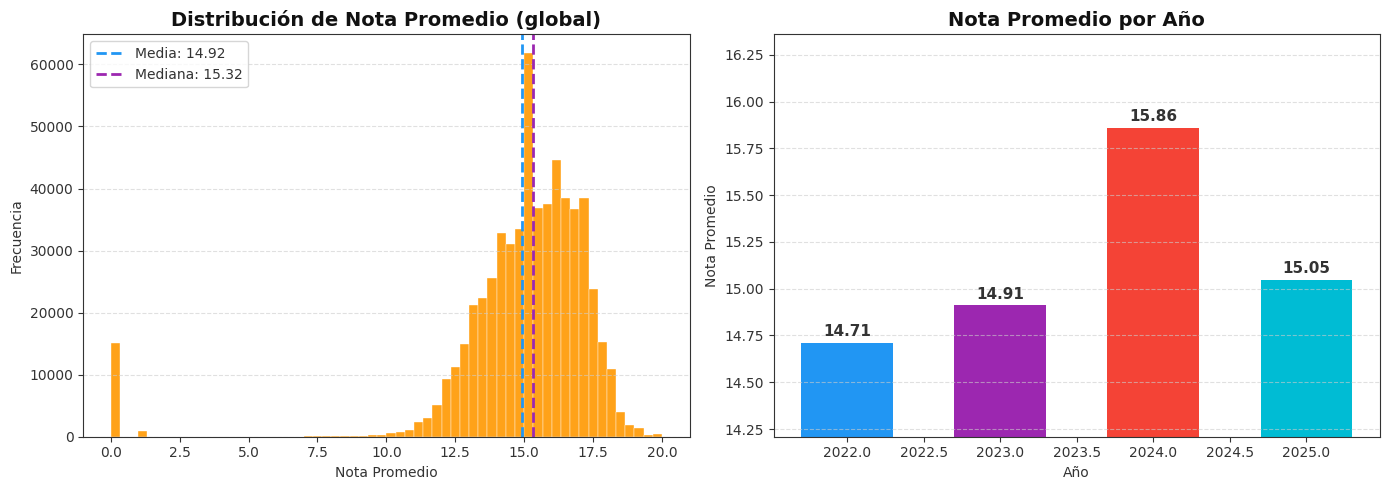

Estadísticas Nota Promedio (global):
count    584314.00
mean         14.92
std           2.98
min           0.00
25%          14.09
50%          15.32
75%          16.55
max          20.00
Name: NOTA_PROMEDIO, dtype: float64

── Nota Promedio por Nivel Académico ──


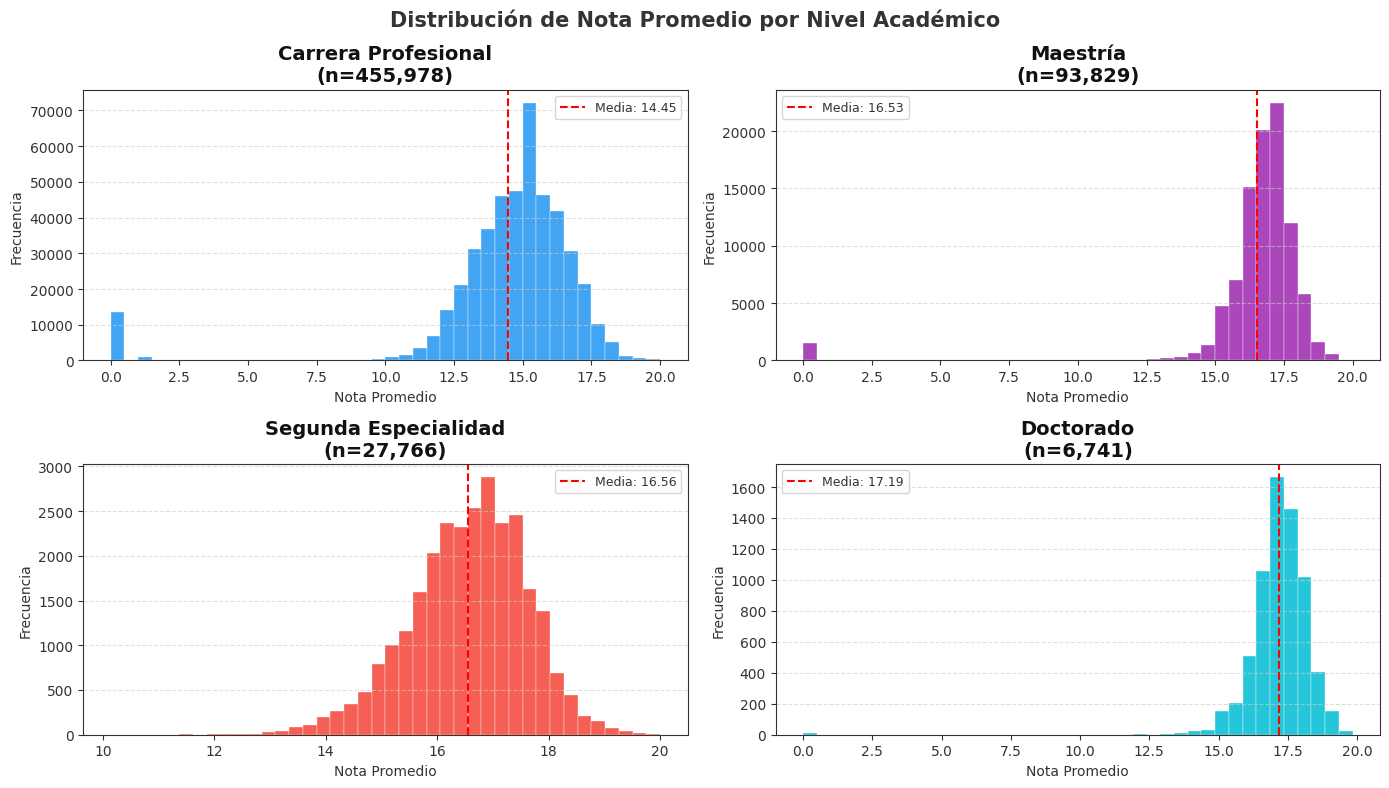

                           N  Media  Mediana  Desv.Std
NIVEL_ACADEMICO                                       
Carrera Profesional   455978  14.45    15.00      3.03
Maestría               93829  16.53    16.88      2.31
Segunda Especialidad   27766  16.56    16.64      1.05
Doctorado               6741  17.19    17.26      1.19


In [14]:
nota_clean = df['NOTA_PROMEDIO'].dropna()
nota_clean = nota_clean[(nota_clean >= 0) & (nota_clean <= 20)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma global
axes[0].hist(nota_clean, bins=60, color=PALETTE[4], edgecolor='white',
             linewidth=0.3, alpha=0.9)
axes[0].axvline(nota_clean.mean(),   color=PALETTE[0], linestyle='--',
                linewidth=2, label=f'Media: {nota_clean.mean():.2f}')
axes[0].axvline(nota_clean.median(), color=PALETTE[1], linestyle='--',
                linewidth=2, label=f'Mediana: {nota_clean.median():.2f}')
axes[0].set_title('Distribución de Nota Promedio (global)')
axes[0].set_xlabel('Nota Promedio')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(axis='y')

# Nota promedio por año
nota_anio = df.groupby('ANIO')['NOTA_PROMEDIO'].mean().reset_index()
axes[1].bar(nota_anio['ANIO'], nota_anio['NOTA_PROMEDIO'],
            color=PALETTE[:4], edgecolor='none', width=0.6)
axes[1].set_ylim(nota_anio['NOTA_PROMEDIO'].min() - 0.5,
                  nota_anio['NOTA_PROMEDIO'].max() + 0.5)
axes[1].set_title('Nota Promedio por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Nota Promedio')
axes[1].grid(axis='y')
for _, row in nota_anio.iterrows():
    axes[1].text(row['ANIO'], row['NOTA_PROMEDIO'] + 0.02,
                 f"{row['NOTA_PROMEDIO']:.2f}",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Estadísticas Nota Promedio (global):')
print(nota_clean.describe().round(2))

# ── Nota Promedio por Nivel Académico ─────────────────────────────────────
print('\n── Nota Promedio por Nivel Académico ──')
df_nota_nivel = df[df['NOTA_PROMEDIO'].between(0, 20)].copy()
niveles = df_nota_nivel['NIVEL_ACADEMICO'].value_counts().index.tolist()

n_niveles = len(niveles)
ncols = 2
nrows = (n_niveles + 1) // ncols
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes2 = axes2.flatten()

for i, nivel in enumerate(niveles):
    sub = df_nota_nivel[df_nota_nivel['NIVEL_ACADEMICO'] == nivel]['NOTA_PROMEDIO']
    axes2[i].hist(sub, bins=40, color=PALETTE[i % len(PALETTE)],
                  edgecolor='white', linewidth=0.3, alpha=0.85)
    axes2[i].axvline(sub.mean(), color='red', linestyle='--', linewidth=1.5,
                     label=f'Media: {sub.mean():.2f}')
    axes2[i].set_title(f'{nivel}\n(n={len(sub):,})')
    axes2[i].set_xlabel('Nota Promedio')
    axes2[i].set_ylabel('Frecuencia')
    axes2[i].legend(fontsize=9)
    axes2[i].grid(axis='y')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Distribución de Nota Promedio por Nivel Académico', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
resumen_nivel = (df_nota_nivel.groupby('NIVEL_ACADEMICO')['NOTA_PROMEDIO']
                 .agg(['count', 'mean', 'median', 'std'])
                 .rename(columns={'count': 'N', 'mean': 'Media',
                                  'median': 'Mediana', 'std': 'Desv.Std'})
                 .round(2)
                 .sort_values('N', ascending=False))
print(resumen_nivel.to_string())

### 4.9 Nota Promedio por Sexo

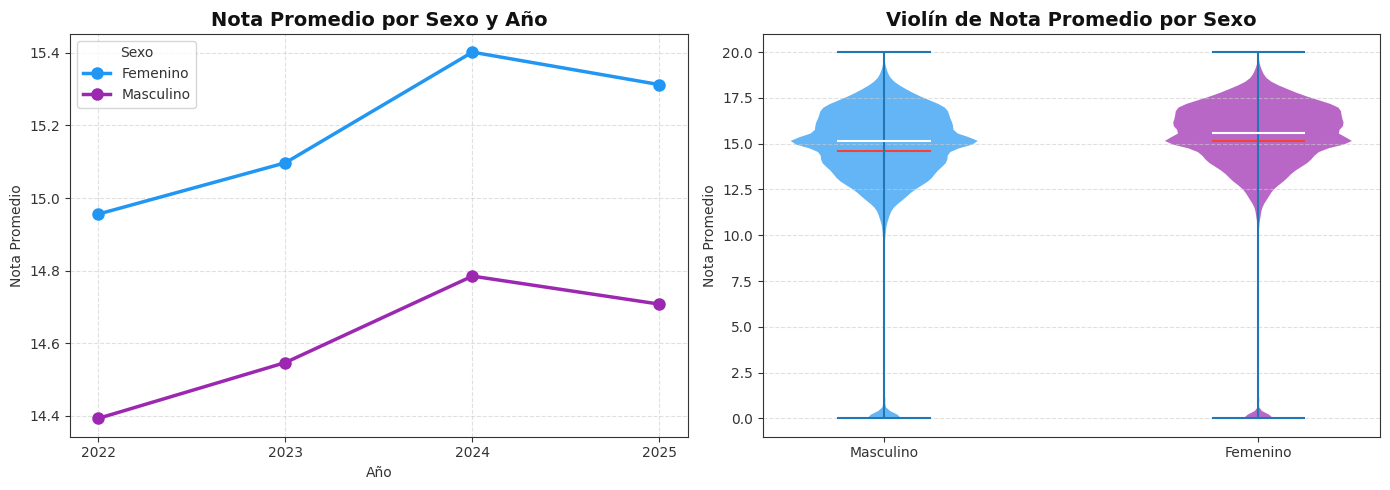

Media por Sexo:
              count   mean   std  min    25%    50%    75%   max
SEXO                                                            
Femenino   327256.0  15.17  2.84  0.0  14.44  15.59  16.69  20.0
Masculino  257058.0  14.59  3.11  0.0  13.72  15.14  16.32  20.0


In [15]:
nota_sexo_anio = (
    df[df['NOTA_PROMEDIO'].between(0, 20)]
    .groupby(['ANIO', 'SEXO'])['NOTA_PROMEDIO']
    .mean()
    .unstack()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Líneas por año
for sexo, color in zip(nota_sexo_anio.columns, PALETTE):
    axes[0].plot(nota_sexo_anio.index, nota_sexo_anio[sexo],
                 marker='o', color=color, linewidth=2.5, markersize=8, label=sexo)
axes[0].set_title('Nota Promedio por Sexo y Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nota Promedio')
axes[0].legend(title='Sexo')
axes[0].grid()
axes[0].set_xticks(YEARS)

# Violin por sexo
df_nota_filt = df[df['NOTA_PROMEDIO'].between(0, 20) & df['SEXO'].isin(['Masculino', 'Femenino'])]
grupos = [df_nota_filt[df_nota_filt['SEXO'] == s]['NOTA_PROMEDIO'].dropna() for s in ['Masculino', 'Femenino']]
vp = axes[1].violinplot(grupos, positions=[1, 2], showmedians=True, showmeans=True)
for pc, color in zip(vp['bodies'], PALETTE):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
vp['cmedians'].set_color('#FFFFFF')
vp['cmeans'].set_color(PALETTE[2])
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Masculino', 'Femenino'])
axes[1].set_title('Violín de Nota Promedio por Sexo')
axes[1].set_ylabel('Nota Promedio')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print('Media por Sexo:')
print(df_nota_filt.groupby('SEXO')['NOTA_PROMEDIO'].describe().round(2))

### 4.10 Créditos Aprobados

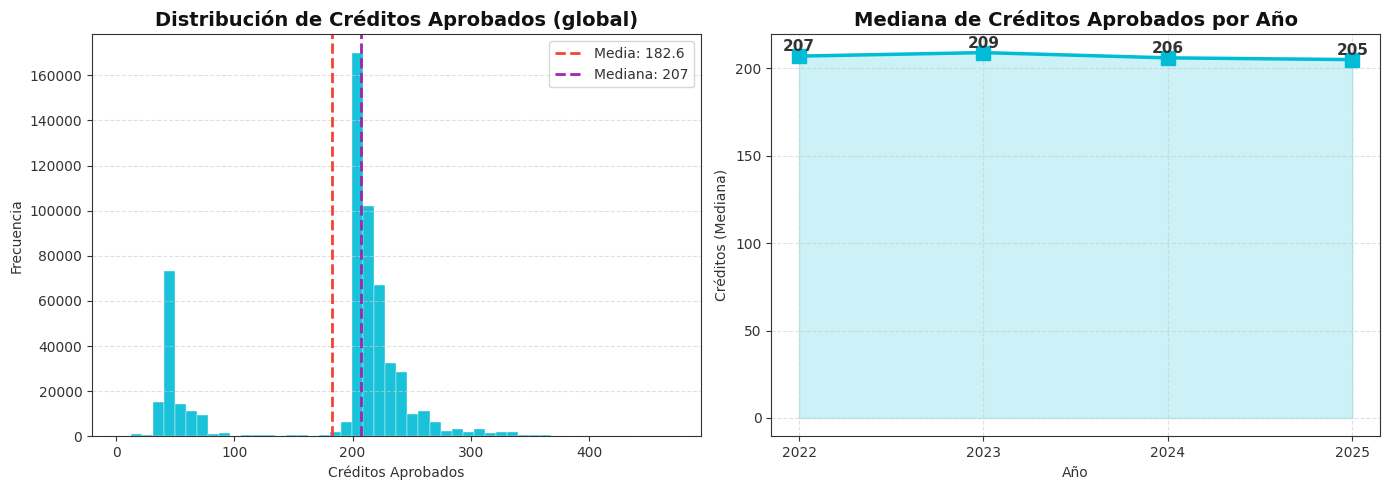

Estadísticas Créditos Aprobados (global):
count    584341.00
mean        182.63
std          73.48
min           3.00
25%         200.00
50%         207.00
75%         221.00
max         471.00
Name: CREDITOS_APROBADOS, dtype: float64

── Créditos Aprobados por Nivel Académico ──


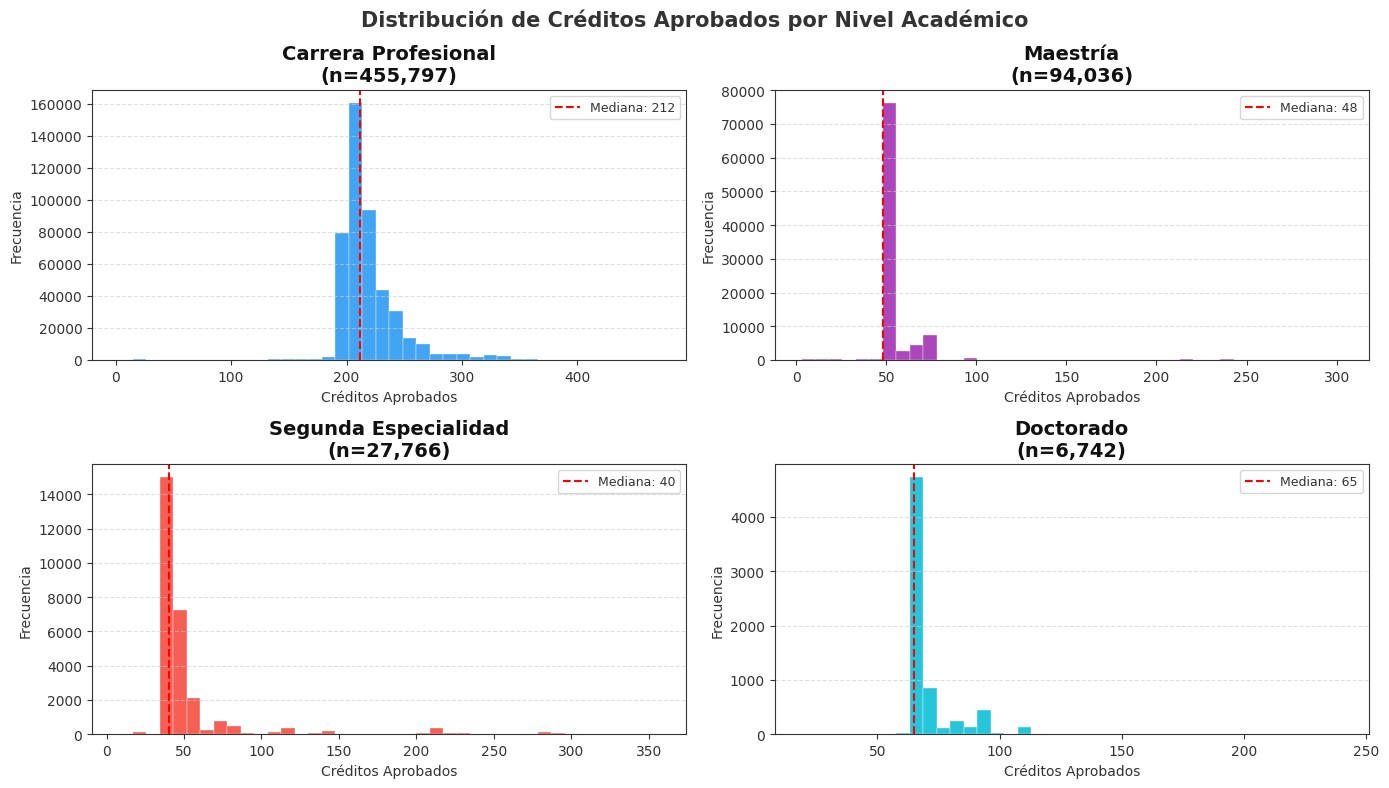

                           N   Media  Mediana  Desv.Std
NIVEL_ACADEMICO                                        
Carrera Profesional   455797  218.99    212.0     27.47
Maestría               94036   52.71     48.0     17.97
Segunda Especialidad   27766   52.90     40.0     36.72
Doctorado               6742   70.36     65.0     12.13


In [16]:
cred_clean = df['CREDITOS_APROBADOS'].dropna()
cred_clean = cred_clean[(cred_clean > 0) & (cred_clean < 500)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma global
axes[0].hist(cred_clean, bins=50, color=PALETTE[3], edgecolor='white',
             linewidth=0.3, alpha=0.9)
axes[0].axvline(cred_clean.mean(), color=PALETTE[2], linestyle='--',
                linewidth=2, label=f'Media: {cred_clean.mean():.1f}')
axes[0].axvline(cred_clean.median(), color=PALETTE[1], linestyle='--',
                linewidth=2, label=f'Mediana: {cred_clean.median():.0f}')
axes[0].set_title('Distribución de Créditos Aprobados (global)')
axes[0].set_xlabel('Créditos Aprobados')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(axis='y')

# Créditos por año
cred_anio = df[df['CREDITOS_APROBADOS'].between(0, 500)].groupby('ANIO')['CREDITOS_APROBADOS'].median()
axes[1].plot(cred_anio.index, cred_anio.values, marker='s',
             color=PALETTE[3], linewidth=2.5, markersize=10)
axes[1].fill_between(cred_anio.index, cred_anio.values, alpha=0.2, color=PALETTE[3])
axes[1].set_title('Mediana de Créditos Aprobados por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Créditos (Mediana)')
axes[1].set_xticks(YEARS)
axes[1].grid()
for x, y in zip(cred_anio.index, cred_anio.values):
    axes[1].text(x, y + 1, f'{y:.0f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Estadísticas Créditos Aprobados (global):')
print(cred_clean.describe().round(2))

# ── Créditos Aprobados por Nivel Académico ────────────────────────────────
print('\n── Créditos Aprobados por Nivel Académico ──')
df_cred_nivel = df[df['CREDITOS_APROBADOS'].between(1, 500)].copy()
niveles_c = df_cred_nivel['NIVEL_ACADEMICO'].value_counts().index.tolist()

n_niv = len(niveles_c)
ncols_c = 2
nrows_c = (n_niv + 1) // ncols_c
fig2, axes2 = plt.subplots(nrows_c, ncols_c, figsize=(14, 4 * nrows_c))
axes2 = axes2.flatten()

for i, nivel in enumerate(niveles_c):
    sub = df_cred_nivel[df_cred_nivel['NIVEL_ACADEMICO'] == nivel]['CREDITOS_APROBADOS']
    axes2[i].hist(sub, bins=40, color=PALETTE[i % len(PALETTE)],
                  edgecolor='white', linewidth=0.3, alpha=0.85)
    axes2[i].axvline(sub.median(), color='red', linestyle='--', linewidth=1.5,
                     label=f'Mediana: {sub.median():.0f}')
    axes2[i].set_title(f'{nivel}\n(n={len(sub):,})')
    axes2[i].set_xlabel('Créditos Aprobados')
    axes2[i].set_ylabel('Frecuencia')
    axes2[i].legend(fontsize=9)
    axes2[i].grid(axis='y')

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Distribución de Créditos Aprobados por Nivel Académico', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
resumen_cred = (df_cred_nivel.groupby('NIVEL_ACADEMICO')['CREDITOS_APROBADOS']
                .agg(['count', 'mean', 'median', 'std'])
                .rename(columns={'count': 'N', 'mean': 'Media',
                                 'median': 'Mediana', 'std': 'Desv.Std'})
                .round(2)
                .sort_values('N', ascending=False))
print(resumen_cred.to_string())

### 4.11 Top 15 Universidades / Instituciones

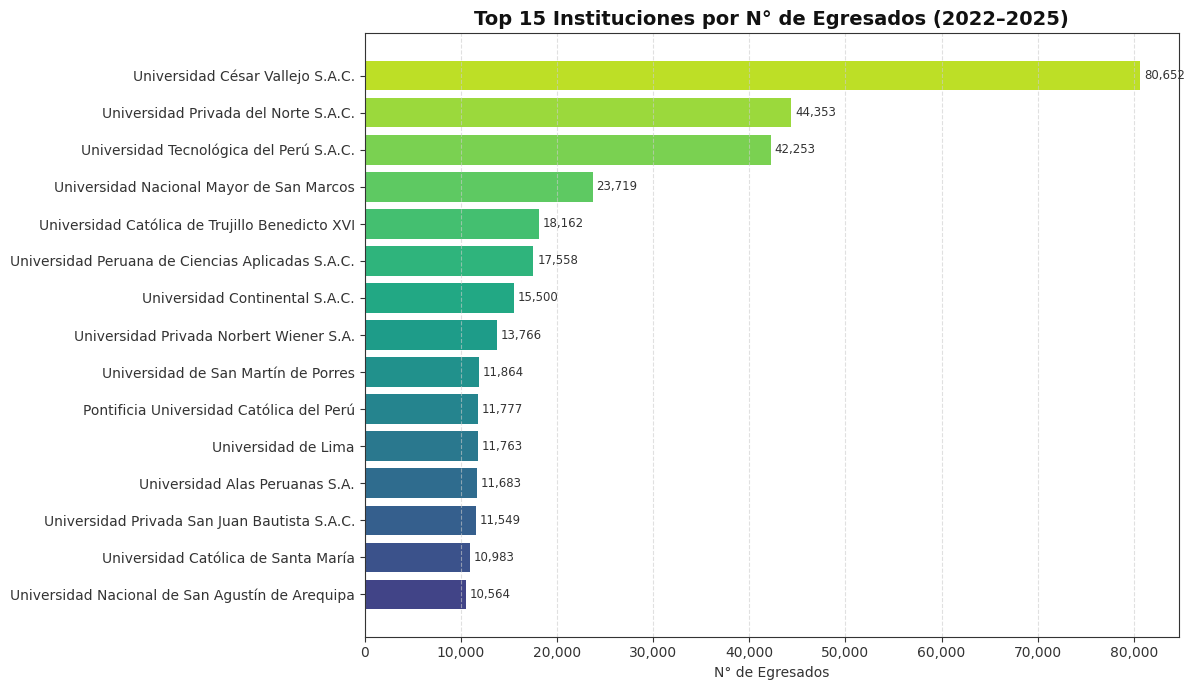

In [17]:
top_univ = df['NOMBRE_ENTIDAD'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors_grad = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_univ)))
bars = ax.barh(top_univ.index[::-1], top_univ.values[::-1], color=colors_grad, edgecolor='none')
ax.set_title('Top 15 Instituciones por N° de Egresados (2022–2025)')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, top_univ.values[::-1]):
    ax.text(bar.get_width() + top_univ.values.max()*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5, )
plt.tight_layout()
plt.show()

### 4.12 Top 15 Programas Académicos

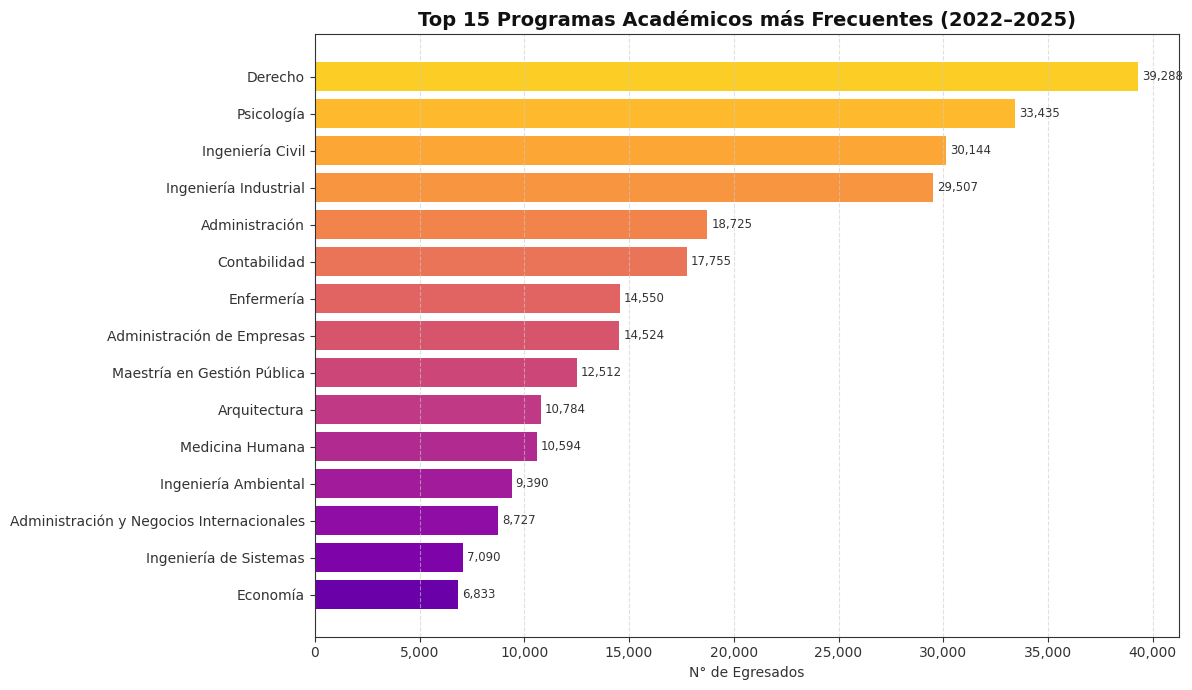

In [18]:
top_prog = df['NOMBRE_PROGRAMA'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors_prog = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_prog)))
bars = ax.barh(top_prog.index[::-1], top_prog.values[::-1], color=colors_prog, edgecolor='none')
ax.set_title('Top 15 Programas Académicos más Frecuentes (2022–2025)')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, top_prog.values[::-1]):
    ax.text(bar.get_width() + top_prog.values.max()*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5, )
plt.tight_layout()
plt.show()

### 4.13 Grupos Académicos (Área de Conocimiento)

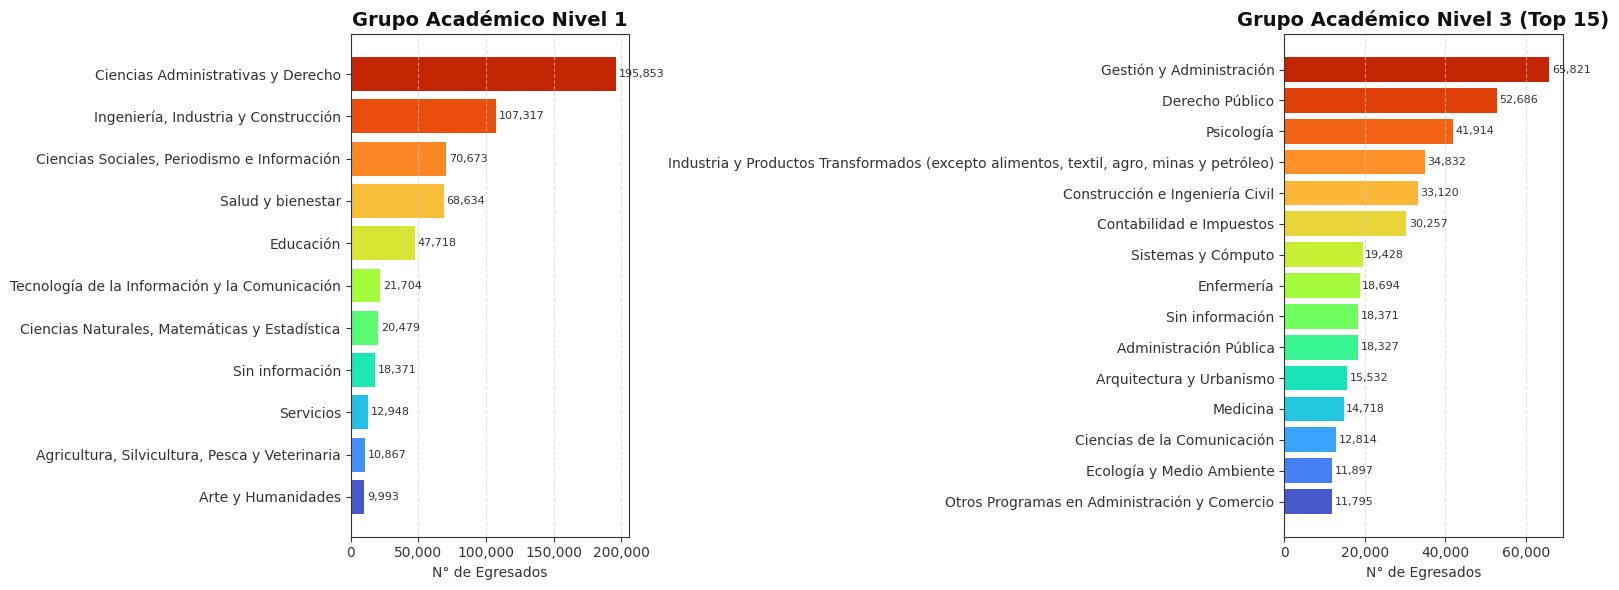

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(
    axes,
    ['NOMBRE_GRUPO_1', 'NOMBRE_GRUPO_3'],
    ['Grupo Académico Nivel 1', 'Grupo Académico Nivel 3 (Top 15)']
):
    counts = df[col].value_counts().head(15)
    colors_g = plt.cm.turbo(np.linspace(0.1, 0.9, len(counts)))
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors_g, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel('N° de Egresados')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='x')
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + counts.values.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8, )

plt.tight_layout()
plt.show()

### 4.17 Egresados con Discapacidad

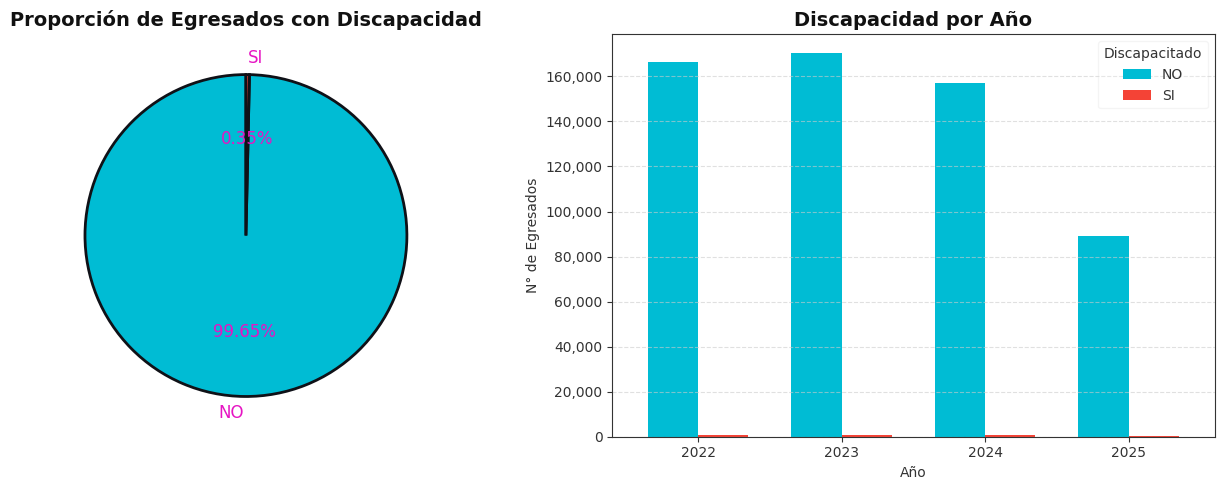

DISCAPACITADO
NO    582510
SI      2047
Name: count, dtype: int64


In [20]:
disc_counts = df['DISCAPACITADO'].value_counts()
disc_anio   = df.groupby(['ANIO', 'DISCAPACITADO']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    disc_counts.values,
    labels=disc_counts.index,
    autopct='%1.2f%%',
    colors=[PALETTE[3], PALETTE[2]],
    startangle=90,
    wedgeprops={'edgecolor': '#0F1117', 'linewidth': 2},
    textprops={'color': '#e615c3', 'fontsize': 12}
)
axes[0].set_title('Proporción de Egresados con Discapacidad')

disc_anio.plot(kind='bar', ax=axes[1], color=[PALETTE[3], PALETTE[2]], edgecolor='none', width=0.7)
axes[1].set_title('Discapacidad por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('N° de Egresados')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Discapacitado', framealpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(disc_counts)

### 4.18 Nacionalidad de los Egresados

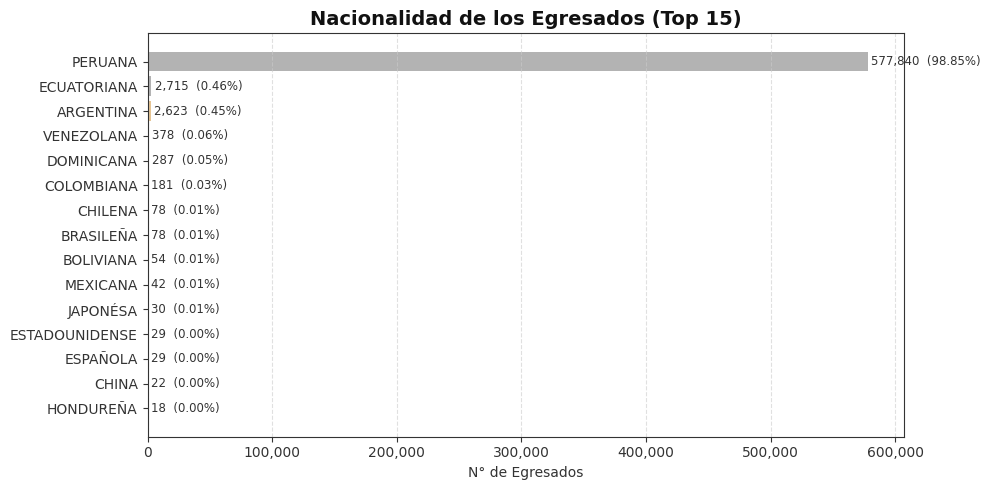

In [21]:
nac_counts = df['NACIONALIDAD'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors_nac = plt.cm.Set2(np.linspace(0, 1, len(nac_counts)))
bars = ax.barh(nac_counts.index[::-1], nac_counts.values[::-1], color=colors_nac, edgecolor='none')
ax.set_title('Nacionalidad de los Egresados (Top 15)')
ax.set_xlabel('N° de Egresados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
for bar, val in zip(bars, nac_counts.values[::-1]):
    ax.text(bar.get_width() + nac_counts.values.max()*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.2f}%)', va='center', fontsize=8.5, )
plt.tight_layout()
plt.show()

### 4.19 Período de Egreso (Semestre)

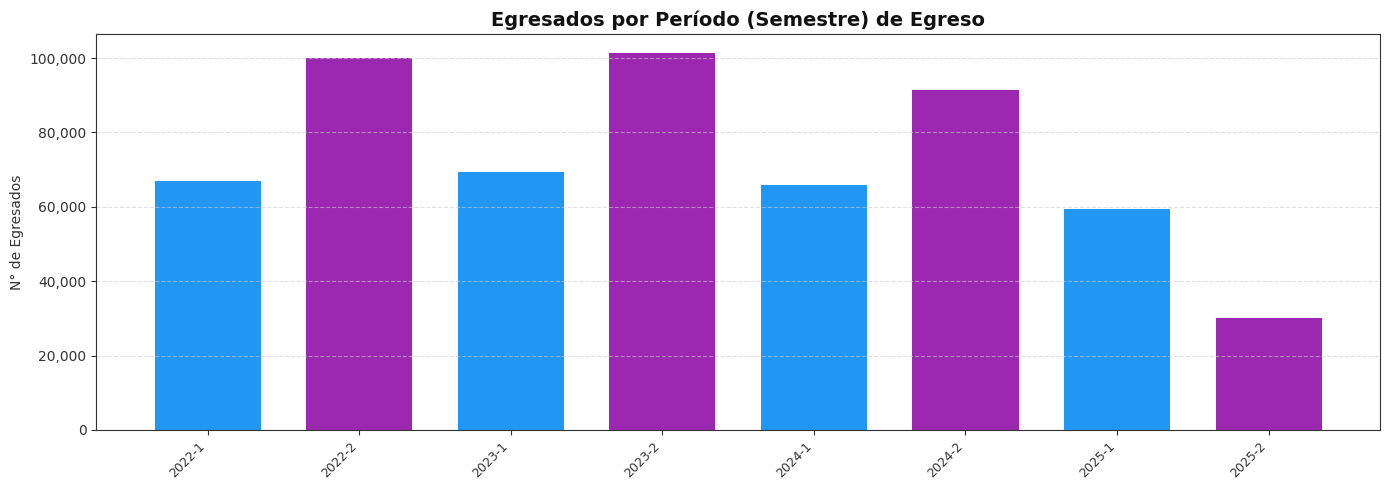

In [22]:
periodo_counts = df['PERIODO_EGRESO'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
colors_periodo = [PALETTE[0] if '-1' in str(p) else PALETTE[1] for p in periodo_counts.index]
bars = ax.bar(range(len(periodo_counts)), periodo_counts.values,
              color=colors_periodo, edgecolor='none', width=0.7)
ax.set_xticks(range(len(periodo_counts)))
ax.set_xticklabels(periodo_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Egresados por Período (Semestre) de Egreso')
ax.set_ylabel('N° de Egresados')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### 4.20 Heatmap de Correlaciones (Variables Numéricas)

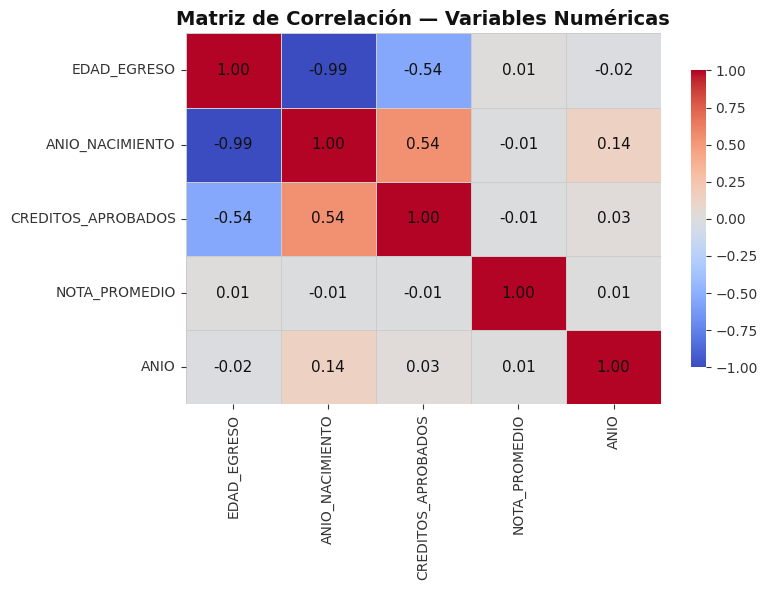


── Correlación Nota Promedio vs Créditos por Nivel Académico ──


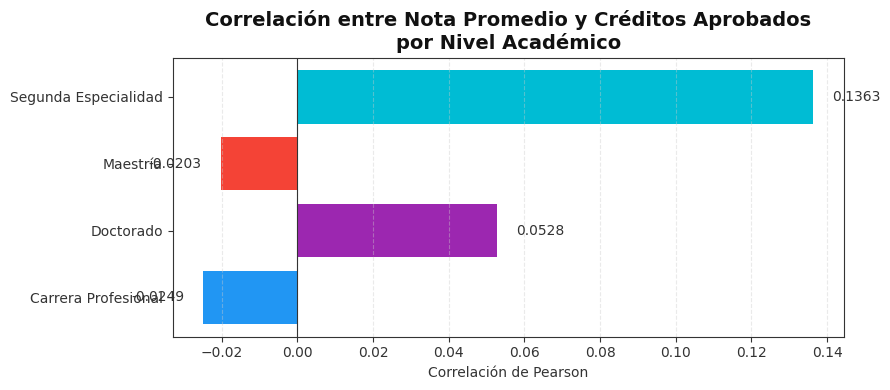

     NIVEL_ACADEMICO  Correlación Nota vs Créditos
 Carrera Profesional                       -0.0249
           Doctorado                        0.0528
            Maestría                       -0.0203
Segunda Especialidad                        0.1363


In [23]:
# Heatmap de correlaciones — Variables Numéricas
num_cols = ['EDAD_EGRESO', 'ANIO_NACIMIENTO', 'CREDITOS_APROBADOS', 'NOTA_PROMEDIO', 'ANIO']
num_cols_exist = [c for c in num_cols if c in df.columns]
df_num = df[num_cols_exist].dropna()

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    linecolor='#CCCCCC',
    annot_kws={'size': 11, 'color': '#111111'},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación — Variables Numéricas')
plt.tight_layout()
plt.show()

# ── Segunda correlación: Nota Promedio vs Créditos por Nivel Académico ───
print('\n── Correlación Nota Promedio vs Créditos por Nivel Académico ──')
df_corr2 = df[df['NOTA_PROMEDIO'].between(0, 20) & df['CREDITOS_APROBADOS'].between(1, 500)]
corr2 = (df_corr2.groupby('NIVEL_ACADEMICO')
         .apply(lambda g: g[['NOTA_PROMEDIO', 'CREDITOS_APROBADOS']].corr()
                .loc['NOTA_PROMEDIO', 'CREDITOS_APROBADOS'])
         .reset_index()
         .rename(columns={0: 'Correlación Nota vs Créditos'}))
corr2['Correlación Nota vs Créditos'] = corr2['Correlación Nota vs Créditos'].round(4)

fig2, ax2 = plt.subplots(figsize=(9, 4))
colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(corr2))]
ax2.barh(corr2['NIVEL_ACADEMICO'], corr2['Correlación Nota vs Créditos'],
         color=colors_bar, edgecolor='none')
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_title('Correlación entre Nota Promedio y Créditos Aprobados\npor Nivel Académico')
ax2.set_xlabel('Correlación de Pearson')
ax2.grid(axis='x', alpha=0.4)
for i, row in corr2.iterrows():
    offset = 0.005 if row['Correlación Nota vs Créditos'] >= 0 else -0.005
    ha = 'left' if row['Correlación Nota vs Créditos'] >= 0 else 'right'
    ax2.text(row['Correlación Nota vs Créditos'] + offset, i,
             f"{row['Correlación Nota vs Créditos']:.4f}",
             va='center', ha=ha, fontsize=10)
plt.tight_layout()
plt.show()
print(corr2.to_string(index=False))

### 4.21 Nota Promedio vs Créditos Aprobados (Scatter)

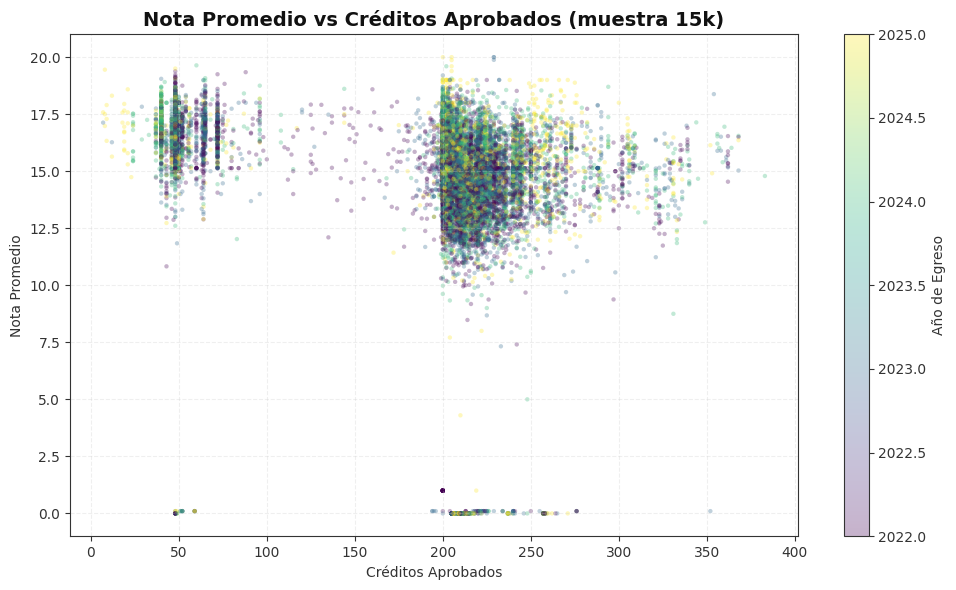

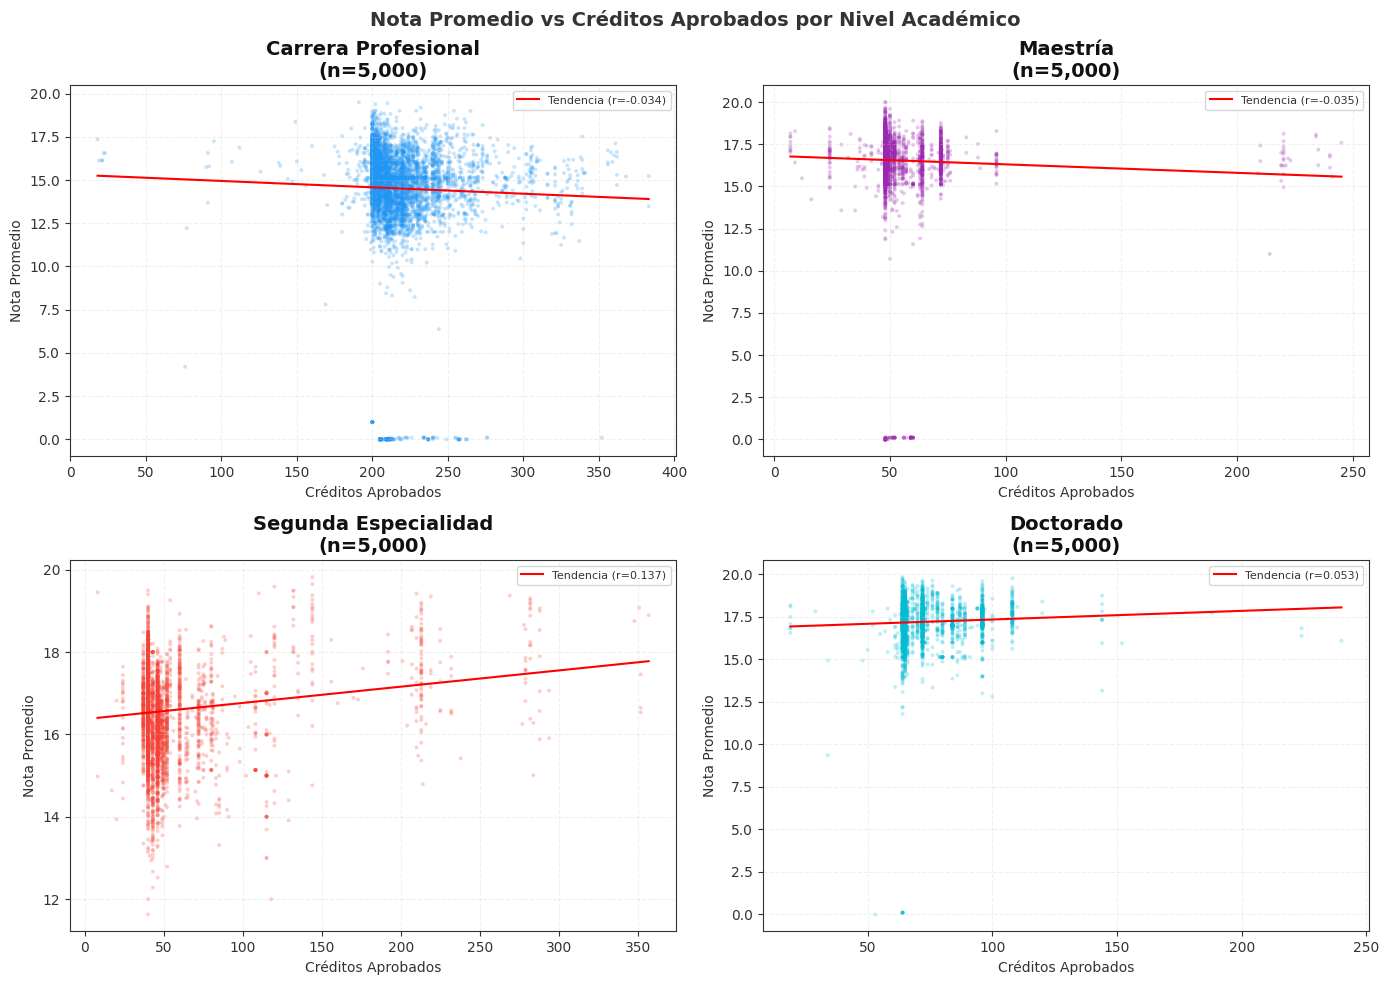

In [24]:
df_scatter = df[
    df['NOTA_PROMEDIO'].between(0, 20) &
    df['CREDITOS_APROBADOS'].between(1, 400)
].sample(min(15000, len(df)), random_state=42)

# Scatter global
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_scatter['CREDITOS_APROBADOS'],
    df_scatter['NOTA_PROMEDIO'],
    c=df_scatter['ANIO'],
    cmap='viridis',
    alpha=0.3,
    s=10,
    edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año de Egreso')
ax.set_title('Nota Promedio vs Créditos Aprobados (muestra 15k)')
ax.set_xlabel('Créditos Aprobados')
ax.set_ylabel('Nota Promedio')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Scatter por Nivel Académico ──────────────────────────────────────────
df_sc_niv = df[
    df['NOTA_PROMEDIO'].between(0, 20) &
    df['CREDITOS_APROBADOS'].between(1, 400)
].copy()
niveles_sc = df_sc_niv['NIVEL_ACADEMICO'].value_counts().index.tolist()

n_sc = len(niveles_sc)
ncols_sc = 2
nrows_sc = (n_sc + 1) // ncols_sc
fig2, axes2 = plt.subplots(nrows_sc, ncols_sc, figsize=(14, 5 * nrows_sc))
axes2 = axes2.flatten()

for i, nivel in enumerate(niveles_sc):
    sub = df_sc_niv[df_sc_niv['NIVEL_ACADEMICO'] == nivel].sample(
        min(5000, len(df_sc_niv[df_sc_niv['NIVEL_ACADEMICO'] == nivel])),
        random_state=42
    )
    axes2[i].scatter(
        sub['CREDITOS_APROBADOS'], sub['NOTA_PROMEDIO'],
        alpha=0.25, s=8, color=PALETTE[i % len(PALETTE)], edgecolors='none'
    )
    # Línea de tendencia
    if len(sub) > 10:
        m, b = np.polyfit(sub['CREDITOS_APROBADOS'], sub['NOTA_PROMEDIO'], 1)
        x_line = np.linspace(sub['CREDITOS_APROBADOS'].min(),
                             sub['CREDITOS_APROBADOS'].max(), 100)
        axes2[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5,
                      label=f'Tendencia (r={sub["NOTA_PROMEDIO"].corr(sub["CREDITOS_APROBADOS"]):.3f})')
    axes2[i].set_title(f'{nivel}\n(n={len(sub):,})')
    axes2[i].set_xlabel('Créditos Aprobados')
    axes2[i].set_ylabel('Nota Promedio')
    axes2[i].legend(fontsize=8)
    axes2[i].grid(alpha=0.3)

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Nota Promedio vs Créditos Aprobados por Nivel Académico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.22 Distribución de Edad por Año y Sexo (Pirámide Poblacional)

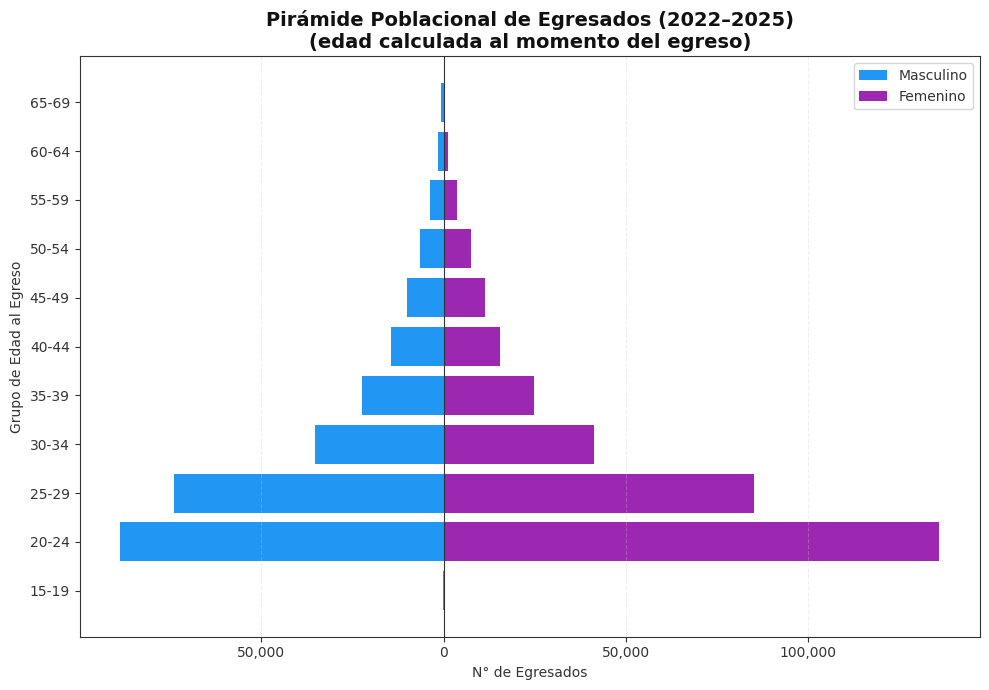

In [25]:
df_pir = df[
    df['SEXO'].isin(['Masculino', 'Femenino']) &
    df['EDAD_EGRESO'].between(15, 70)
].copy()

bins = list(range(15, 75, 5))
labels_edad = [f'{b}-{b+4}' for b in bins[:-1]]
df_pir['GRUPO_EDAD'] = pd.cut(df_pir['EDAD_EGRESO'], bins=bins,
                               labels=labels_edad, right=False)

masc = df_pir[df_pir['SEXO'] == 'Masculino'].groupby('GRUPO_EDAD', observed=True).size()
fem  = df_pir[df_pir['SEXO'] == 'Femenino'].groupby('GRUPO_EDAD',  observed=True).size()

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(labels_edad))
ax.barh(list(y), -masc.values, color=PALETTE[0], label='Masculino', edgecolor='none')
ax.barh(list(y),  fem.values,  color=PALETTE[1], label='Femenino',  edgecolor='none')
ax.set_yticks(list(y))
ax.set_yticklabels(labels_edad)
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Pirámide Poblacional de Egresados (2022–2025)\n(edad calculada al momento del egreso)')
ax.set_xlabel('N° de Egresados')
ax.set_ylabel('Grupo de Edad al Egreso')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.23 Top 10 Programas por Nota Promedio

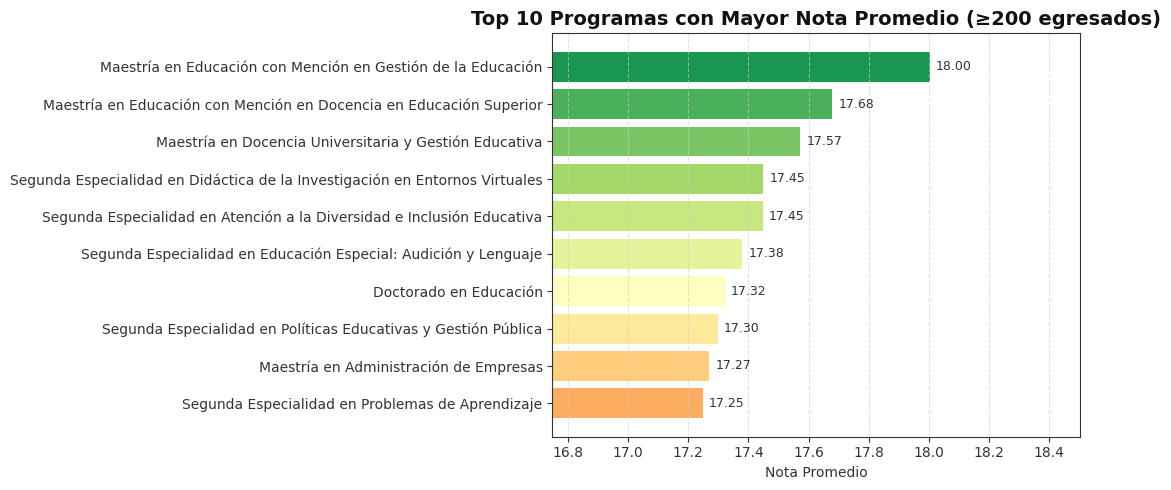

In [26]:
# Solo programas con al menos 200 egresados
prog_nota = (
    df[df['NOTA_PROMEDIO'].between(0, 20)]
    .groupby('NOMBRE_PROGRAMA')
    .agg(N=('NOTA_PROMEDIO', 'count'), Nota_Media=('NOTA_PROMEDIO', 'mean'))
    .query('N >= 300')
    .sort_values('Nota_Media', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
colors_pn = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(prog_nota)))
bars = ax.barh(prog_nota.index[::-1], prog_nota['Nota_Media'][::-1],
               color=colors_pn, edgecolor='none')
ax.set_xlim(prog_nota['Nota_Media'].min() - 0.5, prog_nota['Nota_Media'].max() + 0.5)
ax.set_title('Top 10 Programas con Mayor Nota Promedio (≥200 egresados)')
ax.set_xlabel('Nota Promedio')
ax.grid(axis='x')
for bar, val in zip(bars, prog_nota['Nota_Media'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, )
plt.tight_layout()
plt.show()

### 4.24 Evolución de los 5 Programas más Populares (2022–2025)

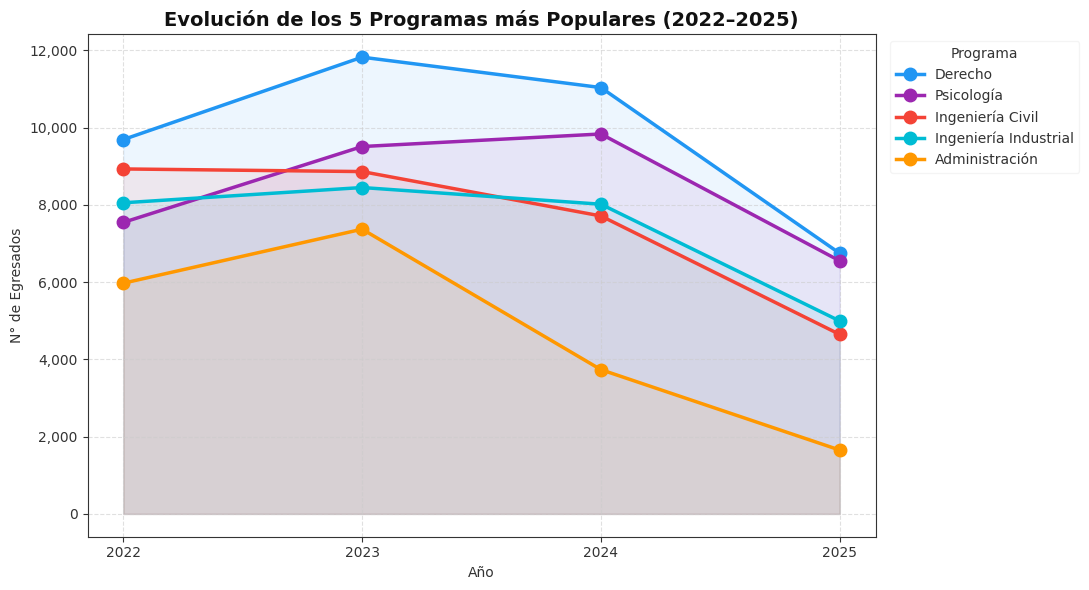

In [27]:
top5_prog = df['NOMBRE_PROGRAMA'].value_counts().head(5).index.tolist()

evol = (
    df[df['NOMBRE_PROGRAMA'].isin(top5_prog)]
    .groupby(['ANIO', 'NOMBRE_PROGRAMA'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))
for i, prog in enumerate(top5_prog):
    ax.plot(evol.index, evol[prog], marker='o', linewidth=2.5,
            markersize=9, color=PALETTE[i], label=prog)
    ax.fill_between(evol.index, evol[prog], alpha=0.08, color=PALETTE[i])

ax.set_title('Evolución de los 5 Programas más Populares (2022–2025)')
ax.set_xlabel('Año')
ax.set_ylabel('N° de Egresados')
ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Programa', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.2)
ax.grid()
plt.tight_layout()
plt.show()

### 4.25 Mapa de Calor: Programa × Año (Top 10)

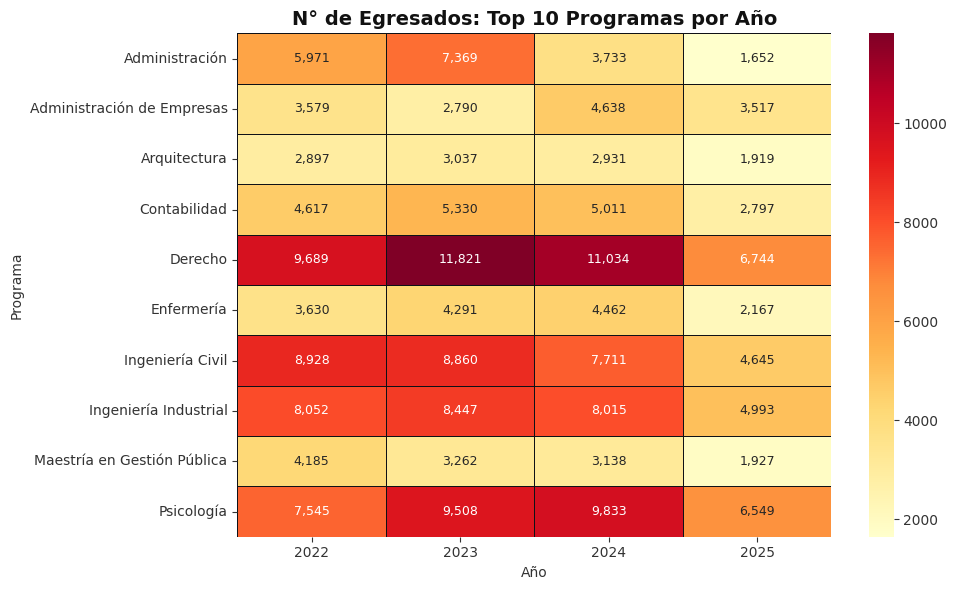

In [28]:
top10_prog = df['NOMBRE_PROGRAMA'].value_counts().head(10).index
heatmap_data = (
    df[df['NOMBRE_PROGRAMA'].isin(top10_prog)]
    .groupby(['NOMBRE_PROGRAMA', 'ANIO'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=',', cmap='YlOrRd',
    linewidths=0.5, linecolor='#0F1117',
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('N° de Egresados: Top 10 Programas por Año')
ax.set_xlabel('Año')
ax.set_ylabel('Programa')
plt.tight_layout()
plt.show()

## 5. Resumen Estadístico Final

In [29]:
print('=' * 65)
print('       RESUMEN EDA — EGRESADOS SUNEDU 2022-2025')
print('=' * 65)
print(f'Total de registros consolidados : {len(df):>15,}')
print(f'Número de variables             : {df.shape[1]:>15}')
print(f'Rango de años                   : {df["ANIO"].min()} – {df["ANIO"].max()}')
print()
print('── Por Año ────────────────────────────────────────────────')
for yr, cnt in df['ANIO'].value_counts().sort_index().items():
    print(f'  {yr}: {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')
print()
print('── Por Sexo ───────────────────────────────────────────────')
for sx, cnt in df['SEXO'].value_counts().items():
    print(f'  {sx:<15}: {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')
print()
print('── Estadísticas Numéricas ─────────────────────────────────')
num_stat_cols = [c for c in ['EDAD_EGRESO', 'NOTA_PROMEDIO', 'CREDITOS_APROBADOS'] if c in df.columns]
print(df[num_stat_cols].describe().round(2).to_string())
print()
print('── Tipo de Gestión ────────────────────────────────────────')
for tg, cnt in df['TIPO_GESTION'].value_counts().items():
    print(f'  {tg:<20}: {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')
print()
print('── Nivel Académico ────────────────────────────────────────')
for niv, cnt in df['NIVEL_ACADEMICO'].value_counts().items():
    print(f'  {niv:<30}: {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')
print()
print('── Discapacidad ───────────────────────────────────────────')
for disc, cnt in df['DISCAPACITADO'].value_counts().items():
    print(f'  {disc:<10}: {cnt:>8,}  ({cnt/len(df)*100:.2f}%)')
print('=' * 65)

       RESUMEN EDA — EGRESADOS SUNEDU 2022-2025
Total de registros consolidados :         584,557
Número de variables             :              21
Rango de años                   : 2022 – 2025

── Por Año ────────────────────────────────────────────────
  2022:  166,944  (28.6%)
  2023:  170,728  (29.2%)
  2024:  157,499  (26.9%)
  2025:   89,386  (15.3%)

── Por Sexo ───────────────────────────────────────────────
  Femenino       :  327,370  (56.0%)
  Masculino      :  257,187  (44.0%)

── Estadísticas Numéricas ─────────────────────────────────
       EDAD_EGRESO  NOTA_PROMEDIO  CREDITOS_APROBADOS
count    584557.00      584557.00           584557.00
mean         29.38          15.13              182.79
std           8.61          52.55               73.95
min          16.00           0.00                3.00
25%          23.00          14.10              200.00
50%          26.00          15.32              207.00
75%          33.00          16.56              221.00
max          

---
## 6. Exportar Dataset Consolidado (Opcional)

In [30]:
# Descomenta para guardar el dataset consolidado
output_path = DATA_DIR / 'egresados_sunedu_2022_2025_consolidado.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'✅ Dataset consolidado guardado en: {output_path}')

✅ Dataset consolidado guardado en: egresados_sunedu_2022_2025_consolidado.csv


In [32]:
# Cargar el CSV guardado
df_guardado = pd.read_csv(output_path, encoding='utf-8-sig')

# Mostrar las primeras filas
df_guardado.head()

,CODIGO_INEI,NOMBRE_ENTIDAD,TIPO_ENTIDAD,TIPO_GESTION,LICENCIADO,TIPO_CONSTITUCION,NIVEL_ACADEMICO,PERIODO_EGRESO,FECHA_EGRESO,SEXO,...,ANIO_NACIMIENTO,NOMBRE_GRUPO_1,NOMBRE_GRUPO_3,NOMBRE_PROGRAMA,CREDITOS_APROBADOS,NOTA_PROMEDIO,DISCAPACITADO,ANIO,IDENTIFICADOR_PERSONA,EDAD_EGRESO
0,260000052,Universidad César Vallejo S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-2,2023-01-02 00:00:00.0000000,Femenino,...,2001.0,Ciencias Administrativas y Derecho,Contabilidad e Impuestos,Contabilidad,204.0,15.15,NO,2022,{5B7E7ADF-991C-46B3-AA42-3F7563652501},21.0
1,260000055,Universidad Privada del Norte S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-1,2022-07-19 00:00:00.0000000,Masculino,...,1999.0,Ciencias Administrativas y Derecho,Gestión y Administración,Administración,185.0,16.97,NO,2022,{62EDEC81-C921-42C0-8AE4-0CDD641D7366},23.0
2,260000052,Universidad César Vallejo S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-1,2022-08-10 00:00:00.0000000,Masculino,...,2000.0,"Ingeniería, Industria y Construcción",Construcción e Ingeniería Civil,Ingeniería Civil,204.0,14.53,NO,2022,{E6199420-FC72-42F2-8040-9820CCDDB984},22.0
3,260000052,Universidad César Vallejo S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-2,2023-01-02 00:00:00.0000000,Femenino,...,1997.0,"Ingeniería, Industria y Construcción",Arquitectura y Urbanismo,Arquitectura,205.0,13.17,NO,2022,{DA43AD51-B5D9-4061-A77F-CD6146D15791},25.0
4,260000055,Universidad Privada del Norte S.A.C.,Universidad,Privado,Licenciada,Societaria- Con fines de lucro,Carrera Profesional,2022-1,2022-07-19 00:00:00.0000000,Femenino,...,2001.0,"Ingeniería, Industria y Construcción",Construcción e Ingeniería Civil,Ingeniería Civil,199.0,16.81,NO,2022,{FA4E6C21-32BA-4DF7-BDBB-690DE40F2D5F},21.0


In [33]:
resumen = pd.DataFrame({
    'Columna': df_guardado.columns,
    'No Nulos': df_guardado.count().values,
    'Nulos': df_guardado.isnull().sum().values
})

display(resumen)

,Columna,No Nulos,Nulos
0,CODIGO_INEI,584557,0
1,NOMBRE_ENTIDAD,584557,0
2,TIPO_ENTIDAD,584557,0
3,TIPO_GESTION,584557,0
4,LICENCIADO,584557,0
5,TIPO_CONSTITUCION,584557,0
6,NIVEL_ACADEMICO,584557,0
7,PERIODO_EGRESO,584557,0
8,FECHA_EGRESO,584557,0
9,SEXO,584557,0


In [34]:
# Cantidad de filas y columnas
print("Dimensiones:", df_guardado.shape)
print("Filas:", df_guardado.shape[0])
print("Columnas:", df_guardado.shape[1])

# Nombres de las columnas
print("\nColumnas:")
for col in df_guardado.columns:
    print("-", col)

Dimensiones: (584557, 21)
Filas: 584557
Columnas: 21

Columnas:
- CODIGO_INEI
- NOMBRE_ENTIDAD
- TIPO_ENTIDAD
- TIPO_GESTION
- LICENCIADO
- TIPO_CONSTITUCION
- NIVEL_ACADEMICO
- PERIODO_EGRESO
- FECHA_EGRESO
- SEXO
- NACIONALIDAD
- ANIO_NACIMIENTO
- NOMBRE_GRUPO_1
- NOMBRE_GRUPO_3
- NOMBRE_PROGRAMA
- CREDITOS_APROBADOS
- NOTA_PROMEDIO
- DISCAPACITADO
- ANIO
- IDENTIFICADOR_PERSONA
- EDAD_EGRESO


In [35]:
df_guardado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584557 entries, 0 to 584556
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CODIGO_INEI            584557 non-null  object 
 1   NOMBRE_ENTIDAD         584557 non-null  object 
 2   TIPO_ENTIDAD           584557 non-null  object 
 3   TIPO_GESTION           584557 non-null  object 
 4   LICENCIADO             584557 non-null  object 
 5   TIPO_CONSTITUCION      584557 non-null  object 
 6   NIVEL_ACADEMICO        584557 non-null  object 
 7   PERIODO_EGRESO         584557 non-null  object 
 8   FECHA_EGRESO           584557 non-null  object 
 9   SEXO                   584557 non-null  object 
 10  NACIONALIDAD           584557 non-null  object 
 11  ANIO_NACIMIENTO        584557 non-null  float64
 12  NOMBRE_GRUPO_1         584557 non-null  object 
 13  NOMBRE_GRUPO_3         584557 non-null  object 
 14  NOMBRE_PROGRAMA        584557 non-nu

---
> **EDA completado listo para pipeline** — Se analizaron **~584,557 registros** de egresados universitarios registrados en SUNEDU entre 2022 y 2025, cubriendo **21 variables** que incluyen: institución, tipo de gestión, licenciamiento, nivel académico, sexo, edad, nota promedio, créditos aprobados, programa de estudio,discapacidad y más.